# Tumor Diagnosis Demo

A Machine Learning notebook for tumor classification using a Linear Support Vector Machine with Stochastic Gradient Descent and 5-fold Cross-Validation for the regularization strength.

## Reference

Scikit-learn documentation: <https://scikit-learn.org/stable/>. The project uses the Wisconsin breast-cancer dataset available through scikit-learn and trains a linear classifier with hinge loss and $\ell_2$ regularization.


## Project overview

We start from a labeled dataset with feature matrix

$$
X \in \mathbb{R}^{n \times p},
$$

where $n$ is the number of tumor samples and $p = 30$ is the number of measured tumor attributes. The labels are stored in

$$
y \in \{0,1\}^n,
$$

with the project convention

$$
0 = \text{malignant},
\qquad
1 = \text{benign}.
$$

The overall workflow is:

- import the required scientific Python libraries
- load and standardize the tumor dataset $X$
- visualize the first two predictor features $x_{1}$ and $x_{2}$
- tune the regularization strength $\alpha$ by **5-fold Cross-Validation**
- train the final model using the selected hyperparameter $\alpha$
- visualize a $2D$ slice of the learned decision boundary

## Imports

The next cell loads the numerical, plotting, and machine-learning tools used throughout the notebook.


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt # for plotting 
import seaborn as sns # for plotting
from sklearn import datasets
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import model_selection as ms

## Loading and standardizing the data

The following cell loads the breast-cancer dataset and immediately standardizes the feature matrix.

If $x_j^{(i)}$ denotes feature $j$ for observation $i$, then standardization replaces it by

$$
z_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j},
$$

where

$$
\mu_j = \frac{1}{n}\sum_{i=1}^n x_j^{(i)},
\qquad
\sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^n \left(x_j^{(i)} - \mu_j\right)^2 }.
$$

This matters because the later optimization is both **linear** and **regularized**. Without scaling, variables with larger numerical ranges can dominate simply because of their units.


In [2]:
cancer_data = datasets.load_breast_cancer()
y = cancer_data.target # Training labels ('malignant = 0', 'benign = 1')
X = cancer_data.data # 30 attributes; https://scikit-learn.org/stable/datasets/index.html#breast-cancer-dataset
X = preprocessing.scale(X) # scale each data attribute to zero-mean and unit variance 

## Visualizing two predictors

The next figure plots the first two standardized features. This gives a quick geometric view of the two diagnosis classes. This is only a $2D$ visualization. The classifier itself will still be trained on **all 30 standardized features**.


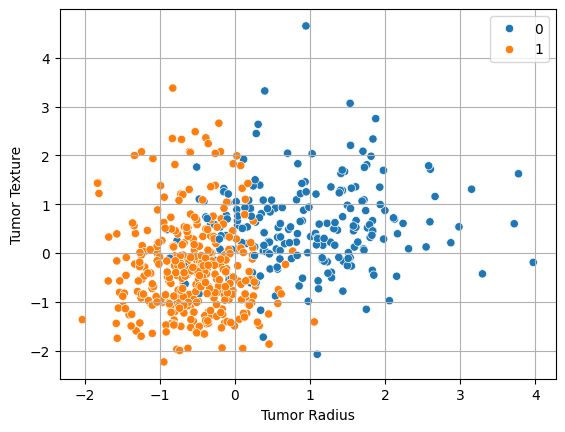

In [3]:
# Plot the first 2 attributes of training points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.xlabel('Tumor Radius')
plt.ylabel('Tumor Texture')
plt.grid(True)
plt.show()

## The learning model

The project uses `SGDClassifier(loss='hinge', penalty='l2')`. Conceptually, this functions as a Linear Support Vector Machine trained by Stochastic Gradient Descent. In particular, using a parameter vector $\theta \in \mathbb{R}^p$ and an offset $\theta_0 \in \mathbb{R}$ we define the linear classifier

$$
h(x) = \operatorname{sign}( \theta \cdot x + \theta_0 ).
$$

Its decision boundary is the hyperplane

$$
\theta \cdot x + \theta_0 = 0.
$$

To express the hinge-loss objective in its usual form, it is convenient to rewrite the labels into $\{-1,+1\}$:

$$
\tilde y^{(i)} = 2y^{(i)} - 1.
$$

Then the regularized objective can be written as

$$
J(\theta,\theta_0)
=
\frac{1}{n}\sum_{i=1}^n
\mathrm{Loss}_h\!\left(\tilde y^{(i)}\bigl(\theta \cdot x^{(i)} + \theta_0\bigr)\right)
+
\frac{\alpha}{2}\lVert \theta \rVert_2^2,
$$

where

$$
\mathrm{Loss}_h(z) = \max\{0, 1-z\}.
$$

The hyperparameter $\alpha$ controls the strength of regularization. The hinge-loss term pushes the model toward correct classification using a margin boundary, while the regularization term keeps the margins large enough to avoid overfitting.

## Cross-Validation loop

The next code cell searches over a grid of candidate regularization strengths $\alpha_i$ for the optimal hyperparameter $\alpha^*$ by using the method of **k-fold Cross-Validation**, specifically $k=5$. First, we start with the standardized data matrix $X$, labels $y$, and define a candidate regularization set $\mathcal{A}$ of increasing $\alpha_i$ as

$$
\mathcal{A}
=
\{\alpha_1, \, \alpha_2, \, \ldots, \, \alpha_m\}.
$$

With 5-fold Cross-Validation, the dataset $D$ is split into five folds

$$
D_1, \, D_2, \, D_3, \, D_4, \, D_5.
$$

For each fold $k$, scikit-learn trains a fresh copy of the estimator on the other four folds,

$$
D_{\mathrm{train}}^{(k)} = D \setminus D_k,
$$

and evaluates it on the held-out fold,

$$
D_{\mathrm{val}}^{(k)} = D_k.
$$

For a fixed $\alpha_i$, this produces 5 training accuracies:

$$
\operatorname{Acc}_1(\alpha_i), \,
\operatorname{Acc}_2(\alpha_i), \,
\operatorname{Acc}_3(\alpha_i), \,
\operatorname{Acc}_4(\alpha_i), \,
\operatorname{Acc}_5(\alpha_i).
$$

Finally, for the given $\alpha_i$ we average over these 5 accuracies to obtain the corresponding Cross-Validation accuracy

$$
\operatorname{CV}(\alpha_i)
=
\frac{1}{5}\sum_{k=1}^{5}\operatorname{Acc}_k(\alpha_i).
$$

The purpose of this algorithm is to identify the optimal hyperparameter defined as

$$
\alpha^\star = \operatorname*{arg} \,
\operatorname*{max}_{\alpha_r \in \mathcal{A}}
\operatorname{CV}(\alpha_i).
$$

In [4]:
# Cross Validation (CV)
alpha = np.arange(1e-15,1,0.005) # Range of hyperparameter values 1E-15 to 1 by 0.005
val_scores = np.zeros(len(alpha)) # Initialize validation score for each alpha value

for i in range(len(alpha)): # for each alpha value
    # Set up SVM with hinge loss and l2 norm regularization
    model = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=alpha[i])
    # Calculate cross validation scores (accuracies) for 5-fold cross-validation
    # Split data into 5 folds; fit on 4/5 and validate on 1/5 (repeated 5 times); returns 5 accuracies
    score = ms.cross_val_score(model, X, y, cv=5)
    val_scores[i] = score.mean() # Calculate mean of the 5 scores (accuracies)

## Validation curve

The next plot shows how the mean cross-validation accuracy $\mathrm{CV}(\alpha)$ changes as a function of $\alpha$. This helps visualize the statistical trade-off:

- very small regularization may let the model fit too aggressively,
- very large regularization may make the classifier too rigid.

The best value is the one that maximizes the validation curve.


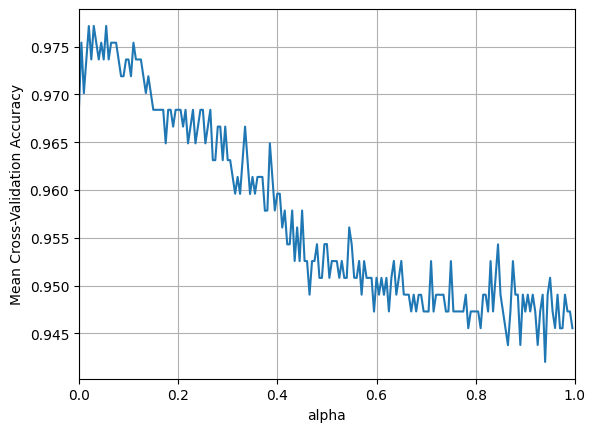

In [5]:
# Plot how cross-validation score changes with alpha
plt.plot(alpha,val_scores)
plt.xlim(0,1)
plt.xlabel('alpha')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

## Selecting the best regularization strength

The next cell identifies the maximizing index and records the chosen value

$$
\alpha^\star = \arg \,
 \max_{\alpha \in \mathcal{A}} \mathrm{CV}(\alpha).
$$

The plot then marks this selected value with a vertical dashed line.

alpha_star = 0.030000000000000998


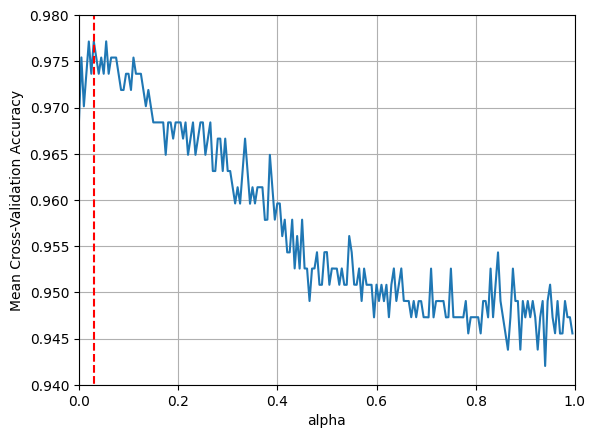

In [6]:
# Determine the alpha that maximizes the cross-validation score
ind = np.argmax(val_scores)
alpha_star = alpha[ind]
print('alpha_star =', alpha_star)

plt.plot(alpha,val_scores)
plt.plot(np.ones(11)*alpha_star,np.arange(0,1.1,0.1),'--r')
plt.xlim(0,1)
plt.ylim(0.94,0.98)
plt.xlabel('alpha')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

## Final training step

After selecting $\alpha^{\star}$, the notebook trains the final classifier on the full standardized dataset. The reported training accuracy is

$$
\mathrm{Acc}_{\mathrm{train}}
=
\frac{1}{n}\sum_{i=1}^n
\mathbf{1}\!\left\{\hat y^{(i)} = y^{(i)}\right\}.
$$

This is useful as a descriptive number, but it should be interpreted carefully: it measures **in-sample fit**, not out-of-sample generalization. The validation curve is the more important object for hyperparameter selection.


In [7]:
# Train model with alpha_star
model_star = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=alpha_star)
model_trained = model_star.fit(X,y)
print('Training Accuracy =', model_trained.score(X,y))
# Training Accuracy = 98% (approximately)

Training Accuracy = 0.9806678383128296


## Geometry of the plotted decision boundary

The final code cell plots a line in the $2D$ plane of the first $2$ standardized predictor features. In the full $30$-dimensional space, the learned decision boundary is

$$
\theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_{30} x_{30} + \theta_0 = 0.
$$

To visualize the above hyperplane in $2D$ space, we create a $2D$ slice by setting

$$
x_3 = x_4 = \cdots = x_{30} = 0.
$$

This reduces the equation to

$$
\theta_1 x_1 + \theta_2 x_2 + \theta_0 = 0.
$$

Solving for $x_2$ gives

$$
x_2 = -\frac{\theta_1}{\theta_2}x_1 - \frac{\theta_0}{\theta_2}.
$$

That is why the line in the code is plotted using

$$
\text{slope} = -\frac{\theta_1}{\theta_2},
\qquad
\text{intercept} = -\frac{\theta_0}{\theta_2}.
$$

This figure is therefore a **2D cross-section** of a boundary learned in $30$ dimensions.


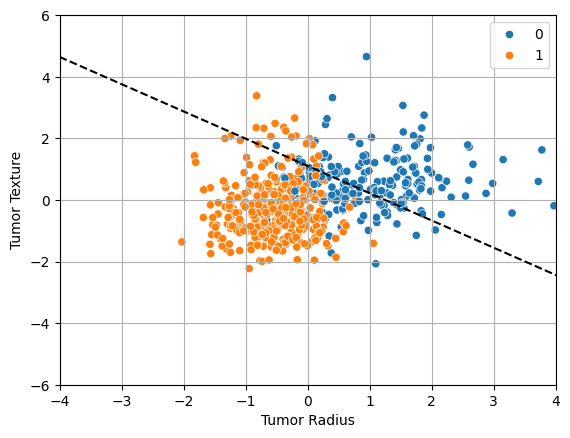

In [8]:
# Plot decision boundary of trained model (in 2D)
# Slice the linear classifier plane equation in 2D by setting X[:,2], ..., X[:,29] = 0 
slope = -model_trained.coef_[0,0]/model_trained.coef_[0,1]
intercept = -model_trained.intercept_[0]/model_trained.coef_[0,1]
x1 = np.arange(-10,10,0.5)
y1 = slope*x1 + intercept
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.plot(x1,y1,'--k')
plt.xlim(-4,4)
plt.ylim(-6,6)
plt.xlabel('Tumor Radius')
plt.ylabel('Tumor Texture')
plt.grid(True)
plt.show()

## Closing remarks

Even though the code in this project is short, it illustrates a full statistical workflow:

- data loading
- feature scaling
- visualization
- model choice
- regularization
- cross-validation
- final fitting
- geometric interpretation